# Consolidated CPI Data Processing and Inflation Analysis

## 1. Overview

This notebook processes the consolidated Consumer Price Index (CPI) dataset and constructs a monthly analytical dataset containing **Headline, Core, and Non-Core CPI inflation**. It additionally retrieves the **RBI Policy Repo Rate through LSEG Workspace** and provides an interactive Plotly visualization comparing inflation dynamics with monetary policy.

The workflow is designed to maintain a clear separation between:

- Raw CPI data
- Data cleaning and filtering
- CPI index construction
- Inflation calculation
- External monetary-policy data
- Analytical output
- Visualization

---

## 2. Input Data

The primary input is the consolidated CPI Excel workbook:

```text
{stub}-b{byear_stub}-data-consolidated.xlsx
```

The expected worksheet is:

```text
CPI-CONSOLIDATED-MASTER
```

The dataset is expected to contain monthly CPI observations together with information on:

- Year
- Month
- Sector
- State / geographical coverage
- CPI Group / Subgroup
- CPI Index

The program dynamically identifies the relevant year, month and classification columns where possible.

---

## 3. Sample Selection

The analysis is restricted to:

1. **Combined sector** observations.
2. **All India / National** observations where such identification is available.
3. Monthly CPI observations.
4. Valid observations required to construct year-on-year inflation.

The resulting data are transformed into a monthly time-series structure with one observation per month.

---

## 4. CPI Index Construction

The analysis decomposes headline CPI into:

- **Headline CPI**
- **Food and Fuel / Non-Core CPI**
- **Core CPI excluding Food and Fuel**

For the CPI Base-2012 analysis, the following weights are used:

| Component | Weight (%) |
|---|---:|
| Food | 45.86 |
| Fuel | 6.84 |
| Food + Fuel | 52.70 |
| Core | 47.30 |

### Non-Core CPI

Non-Core CPI is constructed as the weighted average of Food and Fuel CPI:

\[
NonCore_t =
\frac{
Food_t \times 45.86 +
Fuel_t \times 6.84
}{
52.70
}
\]

### Core CPI

Core CPI is calculated as the residual index after excluding Food and Fuel:

\[
Core_t =
\frac{
Headline_t \times 100 -
Food_t \times 45.86 -
Fuel_t \times 6.84
}{
47.30
}
\]

---

## 5. Inflation Calculation

Inflation is measured as the **year-on-year percentage change** in the corresponding CPI index:

\[
Inflation_t =
\left(
\frac{CPI_t}{CPI_{t-12}}-1
\right)\times100
\]

The following measures are generated:

- Headline CPI inflation
- Core CPI inflation (excluding Food and Fuel)
- Non-Core CPI inflation (Food and Fuel)

The first 12 months of the sample do not have a corresponding year-on-year observation and are therefore excluded from the final analytical dataset.

---

## 6. Analytical Date Range

The analytical period is determined from the available Headline CPI inflation observations.

```text
Minimum date = first valid analytical observation
Maximum date = last valid analytical observation
```

The same date range is subsequently used for the Repo Rate series so that the two datasets are comparable.

---

## 7. RBI Policy Repo Rate

The notebook attempts to retrieve India's **Policy Repo Rate** using the **LSEG Data Library for Python** and an active LSEG Workspace session.

The Python package required is:

```python
import lseg.data as ld
```

The LSEG economic-indicator RIC used for the Repo Rate must be verified through the user's LSEG Workspace / Economic Monitor and appropriate data entitlement.

### Data-integrity principle

The program does **not** silently substitute a manually constructed historical Repo Rate trajectory if the LSEG retrieval fails.

An unsuccessful external-data retrieval should generate an explicit error. This prevents assumed or synthetic policy-rate observations from entering the research dataset without the user's knowledge.

---

## 8. LSEG Data Standardization

Historical observations retrieved from LSEG may return the observation date as an index or under a different column name.

The processing routine therefore:

1. Resets the DataFrame index where required.
2. Identifies the date variable.
3. Converts dates to pandas datetime format.
4. Removes timezone information when necessary.
5. Identifies the Repo Rate variable.
6. Standardizes the output variables as:

```text
date
repo_rate
```

Missing or invalid observations are removed before the series is used.

---

## 9. Output Excel Dataset

The processed CPI dataset is exported to:

```text
{stub}-processed-inflation.xlsx
```

The principal worksheet is:

```text
CPI_Inflation_Processed
```

The worksheet contains the processed monthly CPI analytical variables, including:

- Date
- Headline CPI Index
- Core CPI Index
- Non-Core CPI Index
- Headline CPI inflation
- Core CPI inflation
- Non-Core CPI inflation

The Repo Rate is retrieved separately and can be merged into the analytical dataset where a consolidated CPI–monetary-policy dataset is required.

---

## 10. Interactive Plotly Visualization

The notebook generates an interactive Plotly visualization containing:

- **Headline CPI inflation**
- **Core CPI inflation**
- **Non-Core CPI inflation**
- **RBI Policy Repo Rate**
- **Upper inflation target bound: 6%**
- **Lower inflation target bound: 2%**

The visualization uses a common monthly timeline so that inflation dynamics can be compared with movements in the policy Repo Rate.

The chart also identifies selected inflation-targeting milestones and the peak observed headline CPI inflation during the analytical sample.

---

## 11. HTML Output

The interactive Plotly visualization is exported as:

```text
india-cpi-inflation.html
```

The HTML file can be opened in a web browser and supports:

- Hover information
- Zoom
- Pan
- Legend selection
- Interactive time-series exploration

---

## 12. PNG Output

A high-resolution static version of the visualization is also generated:

```text
india-cpi-inflation.png
```

PNG export requires the **Kaleido** package.

---

## 13. Reproducibility and Data Integrity

The workflow follows the following principles:

- The original consolidated CPI dataset is preserved.
- Transformations are performed on copies of the input data.
- The analytical sample is explicitly defined.
- Dates are standardized before combining different data sources.
- External LSEG data are retrieved separately from CPI data.
- No silent fallback values are inserted when external data retrieval fails.
- CPI inflation and the Repo Rate remain conceptually distinct variables.
- External data-source failures are reported explicitly.

This structure is intended to make the resulting CPI–monetary-policy dataset transparent, reproducible, and suitable for subsequent econometric analysis.

Code run start time: 29/09/2026 19:25:29

Loading consolidated raw dataset from:
/Users/kalyan/Library/CloudStorage/OneDrive-Personal/Kalyan/KK-Python/Kalyan-Jupyter-Notebooks/data/proc-data/cpi-mospi-b2012-data-consolidated.xlsx...

--> Mapped Columns:
    - Headline : 'General-Overall'
    - Food     : 'Consumer Food Price-Overall'
    - Fuel     : 'Fuel and Light-Overall'
--> Requesting LSEG Repo Rate:
    Start : 2014-01-01
    End   : 2025-12-01

--> Raw LSEG response:
aINPRATE    VALUE
Date             
2014-01-31    8.0
2014-04-30    8.0
2014-06-30    8.0
2014-08-31    8.0
2014-09-30    8.0

--> Raw LSEG columns:
['VALUE']

--> Raw LSEG index:
DatetimeIndex(['2014-01-31', '2014-04-30', '2014-06-30', '2014-08-31',
               '2014-09-30', '2014-12-31', '2015-01-31', '2015-02-28',
               '2015-03-31', '2015-04-30', '2015-06-30', '2015-08-31',
               '2015-09-30', '2015-12-31', '2016-02-29', '2016-04-30',
               '2016-06-30', '2016-08-31', '2016-10-31', 

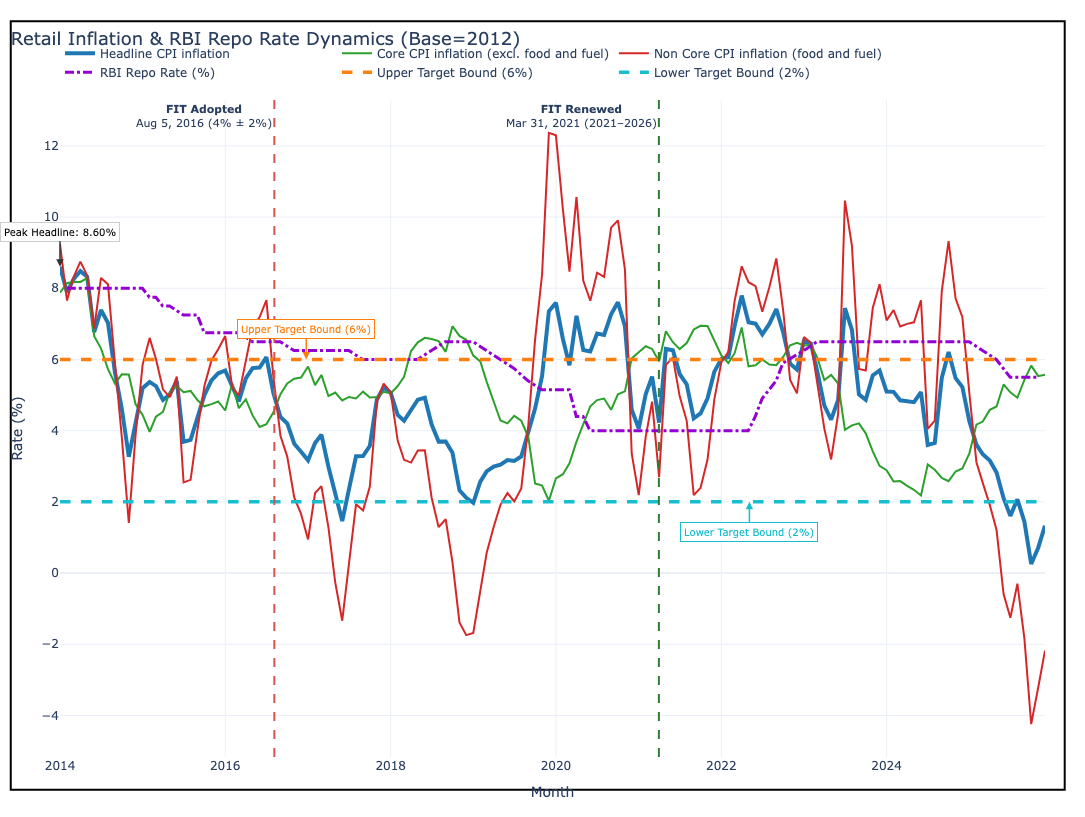


Code run end time: 29/09/2026 19:25:45
Total elapsed time (seconds): 16.22


In [66]:
################################################################################
#                    CONSOLIDATED CPI DATA PROCESSING PIPELINE
################################################################################
#
# PURPOSE
# -------
# This program processes the consolidated Consumer Price Index (CPI) dataset,
# constructs headline, core, and non-core CPI inflation measures, retrieves the
# RBI Policy Repo Rate from LSEG Workspace, and produces an interactive Plotly
# visualization comparing CPI inflation with the monetary policy rate.
#
#
# -------------------------------------------------------------------------------
# 1. INPUT DATA
# -------------------------------------------------------------------------------
#
# The primary input is a consolidated CPI Excel workbook containing monthly
# CPI observations.
#
# Input file:
#
#     {stub}-b{byear_stub}-data-consolidated.xlsx
#
# The workbook is expected to contain the sheet:
#
#     CPI-CONSOLIDATED-MASTER
#
# The input dataset should contain, where available:
#
#     - Year / extracted_year
#     - Month / extracted_month
#     - Sector
#     - State
#     - Group / Subgroup
#     - CPI Index
#
# The program identifies the appropriate year, month, classification and index
# columns dynamically where possible.
#
# The analysis is restricted to:
#
#     - Combined sector / All-India observations
#     - Monthly observations
#
#
# -------------------------------------------------------------------------------
# 2. DATA PREPARATION
# -------------------------------------------------------------------------------
#
# Column names are standardized by:
#
#     - Removing leading and trailing whitespace
#     - Converting column names to lower case
#
# The program then:
#
#     1. Filters the consolidated dataset to the Combined sector.
#     2. Restricts observations to All India / National level where available.
#     3. Converts the CPI index variable to numeric format.
#     4. Constructs a monthly date variable using year and month.
#     5. Reshapes the data from long to wide format.
#
# Each row of the resulting dataset represents one calendar month and each
# CPI group/subgroup becomes a separate column.
#
#
# -------------------------------------------------------------------------------
# 3. CPI COMPONENT IDENTIFICATION
# -------------------------------------------------------------------------------
#
# The program automatically attempts to identify:
#
#     - Headline CPI
#     - Food CPI
#     - Fuel CPI
#
# based on the corresponding column descriptions.
#
# Headline CPI is used as the principal measure of retail inflation.
#
#
# -------------------------------------------------------------------------------
# 4. CPI AGGREGATION
# -------------------------------------------------------------------------------
#
# The following weights are used for the Base-2012 CPI decomposition:
#
#     Food       = 45.86 percent
#     Fuel       =  6.84 percent
#     Food+Fuel  = 52.70 percent
#     Core       = 47.30 percent
#
# Non-Core CPI is constructed as the weighted index of Food and Fuel:
#
#     Non-Core CPI =
#
#       (Food CPI × Food Weight
#        + Fuel CPI × Fuel Weight)
#       --------------------------------
#                 Food + Fuel Weight
#
# Core CPI is obtained as the residual CPI index after excluding Food and Fuel:
#
#     Core CPI =
#
#       (Headline CPI × 100
#        - Food CPI × Food Weight
#        - Fuel CPI × Fuel Weight)
#       --------------------------------
#                  Core Weight
#
# These calculations produce three index series:
#
#     - Headline CPI Index
#     - Core CPI Index
#     - Non-Core CPI Index
#
#
# -------------------------------------------------------------------------------
# 5. INFLATION CALCULATION
# -------------------------------------------------------------------------------
#
# Monthly year-on-year inflation is calculated using the 12-month percentage
# change in the corresponding CPI index:
#
#     Inflation_t =
#
#       [(CPI_t / CPI_(t-12)) - 1] × 100
#
# The following inflation measures are generated:
#
#     - Headline CPI inflation
#     - Core CPI inflation (excluding Food and Fuel)
#     - Non-Core CPI inflation (Food and Fuel)
#
# The first 12 months do not have a YoY inflation observation and are therefore
# excluded from the final analytical dataset.
#
#
# -------------------------------------------------------------------------------
# 6. DATE RANGE
# -------------------------------------------------------------------------------
#
# The analytical sample is defined by the available Headline CPI inflation
# observations.
#
#     min_date = first valid analytical date
#     max_date = last valid analytical date
#
# These dates define the common period used for the CPI and Repo Rate series.
#
#
# -------------------------------------------------------------------------------
# 7. RBI POLICY REPO RATE
# -------------------------------------------------------------------------------
#
# The program attempts to retrieve India's Policy Repo Rate through the
# LSEG Data Library using an active LSEG Workspace session.
#
# Required Python package:
#
#     lseg-data
#
# Python import:
#
#     import lseg.data as ld
#
# The LSEG economic-indicator RIC used for the Repo Rate must be verified
# against the user's LSEG Workspace entitlement / Economic Monitor.
#
# The program deliberately does NOT create an artificial fallback Repo Rate
# trajectory if the LSEG retrieval fails.
#
# This is important for research integrity: an API failure should be visible
# rather than being silently replaced with assumed historical values.
#
# The retrieved LSEG data are standardized to:
#
#     date
#     repo_rate
#
# The Repo Rate series is then restricted to the same analytical period as
# the CPI inflation data.
#
#
# -------------------------------------------------------------------------------
# 8. LSEG DATE AND VARIABLE STANDARDIZATION
# -------------------------------------------------------------------------------
#
# Because LSEG historical data may return the observation date as an index or
# under a different column name, the program:
#
#     - Resets the index where necessary.
#     - Identifies the date column.
#     - Converts the date to pandas datetime.
#     - Removes timezone information where necessary.
#     - Identifies the Repo Rate observation column.
#     - Renames the standardized variables to:
#
#           date
#           repo_rate
#
# Invalid or missing observations are removed.
#
#
# -------------------------------------------------------------------------------
# 9. CONSOLIDATED ANALYTICAL DATA
# -------------------------------------------------------------------------------
#
# The final CPI analytical dataset contains the monthly:
#
#     - Date
#     - Headline CPI Index
#     - Core CPI Index
#     - Non-Core CPI Index
#     - Headline CPI inflation
#     - Core CPI inflation
#     - Non-Core CPI inflation
#
# The Repo Rate is maintained as a separate series and used for visualization
# and subsequent analysis.
#
#
# -------------------------------------------------------------------------------
# 10. OUTPUT EXCEL FILE
# -------------------------------------------------------------------------------
#
# The processed analytical CPI dataset is exported to:
#
#     {stub}-processed-inflation.xlsx
#
# Main output sheet:
#
#     CPI_Inflation_Processed
#
# This sheet contains the cleaned monthly CPI analytical dataset.
#
# The Repo Rate can subsequently be merged into this sheet if a consolidated
# CPI-Monetary Policy dataset is required.
#
#
# -------------------------------------------------------------------------------
# 11. INTERACTIVE PLOTLY VISUALIZATION
# -------------------------------------------------------------------------------
#
# The program generates an interactive Plotly visualization containing:
#
#     1. Headline CPI inflation
#     2. Core CPI inflation
#     3. Non-Core CPI inflation
#     4. RBI Policy Repo Rate
#     5. Upper CPI inflation target bound (6 percent)
#     6. Lower CPI inflation target bound (2 percent)
#
# The CPI inflation target corridor is shown as 2 percent to 6 percent.
#
# The visualization also identifies:
#
#     - Adoption of the Flexible Inflation Targeting framework
#     - Renewal of the inflation-targeting framework
#     - Peak headline CPI inflation during the sample
#
#
# -------------------------------------------------------------------------------
# 12. HTML OUTPUT
# -------------------------------------------------------------------------------
#
# The interactive Plotly figure is embedded in an HTML document and saved as:
#
#     india-cpi-inflation.html
#
# The HTML output can be opened in a standard web browser and provides
# interactive hover, zoom, pan and legend functionality.
#
#
# -------------------------------------------------------------------------------
# 13. PNG OUTPUT
# -------------------------------------------------------------------------------
#
# A high-resolution PNG version of the Plotly visualization is also generated:
#
#     india-cpi-inflation.png
#
# PNG export requires the Kaleido package.
#
#
# -------------------------------------------------------------------------------
# 14. RESEARCH / DATA-INTEGRITY PRINCIPLES
# -------------------------------------------------------------------------------
#
# The pipeline follows the following principles:
#
#     - Preserve the original consolidated CPI dataset.
#     - Perform transformations on copies of the data.
#     - Explicitly define the analytical sample.
#     - Avoid silently replacing missing external data with assumed values.
#     - Standardize dates before merging different data sources.
#     - Preserve the distinction between CPI inflation and the policy rate.
#     - Keep external LSEG data retrieval transparent and reproducible.
#
# Any failure in retrieving the LSEG Repo Rate should generate an explicit
# error rather than silently introducing a synthetic or assumed policy-rate
# series.
#
################################################################################

import os
import time
from datetime import datetime
import pandas as pd
import requests
import plotly.graph_objects as go

# --------------------------------------------
# TIMER & START TIME
# --------------------------------------------
code_start_time = datetime.now()
timer_start = time.time()
print("Code run start time:", code_start_time.strftime("%d/%m/%Y %H:%M:%S"))

# --------------------------------------------
# ========= CONFIGURE PATHS & STUBS =========
# --------------------------------------------
proj_stub = r"/Users/kalyan/Library/CloudStorage/OneDrive-Personal/Kalyan/KK-Python/Kalyan-Jupyter-Notebooks/data/"
stub = r"cpi-mospi"
byear_stub = r"2012"  # Standard CPI Base Year

BASE_DIR = f"{proj_stub}"
RAW_DIR = os.path.join(BASE_DIR, f"raw-data/{stub}")
INTERIM_DIR = os.path.join(BASE_DIR, "interim-data")
PROCESSED_DIR = os.path.join(BASE_DIR, "proc-data")

os.makedirs(PROCESSED_DIR, exist_ok=True)

# File Paths
cpi_master_data_file = os.path.join(PROCESSED_DIR, f"{stub}-b{byear_stub}-data-consolidated.xlsx")
processed_output_excel = os.path.join(PROCESSED_DIR, f"{stub}-processed-inflation.xlsx")
# output_html = os.path.join(PROCESSED_DIR,"india-cpi-inflation.html")
output_html = "india-cpi-inflation.html"
# output_png =  os.path.join(PROCESSED_DIR,"india-cpi-inflation.png")
output_png =  "india-cpi-inflation.png"

# --------------------------------------------
# HELPER: FETCH RBI REPO RATE
# --------------------------------------------
# --------------------------------------------
# HELPER: FETCH RBI REPO RATE FROM LSEG
# --------------------------------------------

def fetch_lseg_repo_rate(date_series, start_date=None, end_date=None):
    """
    Retrieve India's policy Repo Rate from LSEG Workspace.

    Returns a standardized DataFrame with exactly:
        date
        repo_rate

    The function does NOT silently create fallback data.
    """

    import lseg.data as ld
    import pandas as pd

    # ---------------------------------------------------------
    # Determine requested date range
    # ---------------------------------------------------------

    date_series = pd.to_datetime(date_series, errors="coerce").dropna()

    if date_series.empty:
        raise ValueError("date_series contains no valid dates.")

    if start_date is None:
        start_date = date_series.min().strftime("%Y-%m-%d")

    if end_date is None:
        end_date = date_series.max().strftime("%Y-%m-%d")

    print(f"--> Requesting LSEG Repo Rate:")
    print(f"    Start : {start_date}")
    print(f"    End   : {end_date}")

    # ---------------------------------------------------------
    # LSEG Repo Rate RIC
    # ---------------------------------------------------------

    repo_ric = "aINPRATE"

    try:

        # Open Workspace session
        ld.open_session()

        # -----------------------------------------------------
        # Retrieve data
        # -----------------------------------------------------

        df = ld.get_history(
            universe=[repo_ric],
            interval="monthly",
            start=start_date,
            end=end_date
        )

        if df is None or df.empty:
            raise ValueError(
                f"LSEG returned no observations for {repo_ric}."
            )

        # -----------------------------------------------------
        # Inspect original LSEG response
        # -----------------------------------------------------

        print("\n--> Raw LSEG response:")
        print(df.head())

        print("\n--> Raw LSEG columns:")
        print(df.columns.tolist())

        print("\n--> Raw LSEG index:")
        print(df.index)

        # -----------------------------------------------------
        # Convert index to column
        # -----------------------------------------------------

        df = df.reset_index()

        print("\n--> Columns after reset_index:")
        print(df.columns.tolist())

        # -----------------------------------------------------
        # Identify DATE column
        # -----------------------------------------------------

        date_candidates = [
            c for c in df.columns
            if str(c).strip().lower()
            in ["date", "datetime", "timestamp"]
        ]

        if date_candidates:

            date_col = date_candidates[0]

        else:

            # If LSEG gives the date as the first column
            # after reset_index(), use that column.
            date_col = df.columns[0]

            print(
                f"--> Date column not explicitly named 'date'. "
                f"Using first column: {date_col}"
            )

        # -----------------------------------------------------
        # Identify REPO RATE column
        # -----------------------------------------------------

        rate_candidates = [
            c for c in df.columns
            if c != date_col
        ]

        if not rate_candidates:
            raise ValueError(
                "Could not identify the Repo Rate column "
                "in the LSEG response."
            )

        # Since we requested one RIC, there should normally
        # be exactly one data column.
        rate_col = rate_candidates[0]

        print(f"--> Identified date column : {date_col}")
        print(f"--> Identified rate column : {rate_col}")

        # -----------------------------------------------------
        # Standardize columns
        # -----------------------------------------------------

        df_repo = df[[date_col, rate_col]].copy()

        df_repo.columns = [
            "date",
            "repo_rate"
        ]

        # -----------------------------------------------------
        # Convert date and rate
        # -----------------------------------------------------

        df_repo["date"] = pd.to_datetime(
            df_repo["date"],
            errors="coerce"
        )

        df_repo["repo_rate"] = pd.to_numeric(
            df_repo["repo_rate"],
            errors="coerce"
        )

        # Remove invalid observations
        df_repo = df_repo.dropna(
            subset=["date", "repo_rate"]
        )

        # -----------------------------------------------------
        # Remove timezone if LSEG supplies one
        # -----------------------------------------------------

        if hasattr(df_repo["date"].dt, "tz"):

            if df_repo["date"].dt.tz is not None:
                df_repo["date"] = (
                    df_repo["date"]
                    .dt
                    .tz_localize(None)
                )

        # -----------------------------------------------------
        # Sort
        # -----------------------------------------------------

        df_repo = (
            df_repo
            .sort_values("date")
            .drop_duplicates("date")
            .reset_index(drop=True)
        )

        # -----------------------------------------------------
        # Strict date filtering
        # -----------------------------------------------------

        min_date = date_series.min()
        max_date = date_series.max()

        df_repo = df_repo[
            (df_repo["date"] >= min_date) &
            (df_repo["date"] <= max_date)
        ].copy()

        print(
            f"\n--> Retrieved {len(df_repo)} Repo Rate observations."
        )

        print(
            f"--> Repo Rate range: "
            f"{df_repo['date'].min()} "
            f"to "
            f"{df_repo['date'].max()}"
        )

        return df_repo

    except Exception as e:

        raise RuntimeError(
            f"LSEG Repo Rate retrieval failed: {e}"
        ) from e

# --------------------------------------------
# STEP 1: LOAD CONSOLIDATED CPI DATA
# --------------------------------------------
print(f"\nLoading consolidated raw dataset from:\n{cpi_master_data_file}...")
raw_df = pd.read_excel(cpi_master_data_file, sheet_name="CPI-CONSOLIDATED-MASTER")

# Standardize column headers
raw_df.columns = raw_df.columns.str.strip().str.lower()

# --------------------------------------------
# STEP 2: FILTER COMBINED ALL-INDIA LEVEL DATA
# --------------------------------------------
filtered_df = raw_df.copy()

if 'sector' in filtered_df.columns:
    filtered_df = filtered_df[
        filtered_df['sector'].astype(str).str.contains('Combined|3', case=False, na=False)
    ].copy()

if 'state' in filtered_df.columns:
    all_india_mask = filtered_df['state'].astype(str).str.contains('All India|National', case=False, na=False)
    if all_india_mask.any():
        filtered_df = filtered_df[all_india_mask].copy()

# --------------------------------------------
# STEP 3: RESHAPE & PIVOT TIME SERIES
# --------------------------------------------
year_col = 'extracted_year' if 'extracted_year' in filtered_df.columns else 'year'
month_col = 'extracted_month' if 'extracted_month' in filtered_df.columns else 'month'

desc_col = 'subgroup' if 'subgroup' in filtered_df.columns else 'group'
val_col = 'index'

filtered_df[val_col] = pd.to_numeric(filtered_df[val_col], errors='coerce')

filtered_df['date'] = pd.to_datetime(
    filtered_df[year_col].astype(str) + '-' + filtered_df[month_col].astype(str).str.zfill(2) + '-01'
)

df_pivoted = filtered_df.pivot_table(
    index='date',
    columns=desc_col,
    values=val_col,
    aggfunc='mean'
).reset_index().sort_values('date')

df_pivoted['Month'] = df_pivoted['date'].dt.strftime('%b %Y')

cols = df_pivoted.columns.tolist()

headline_col = next((c for c in cols if 'general' in str(c).lower() or 'headline' in str(c).lower() or str(c).lower() == 'cpi'), None)
food_col = next((c for c in cols if 'food' in str(c).lower()), None)
fuel_col = next((c for c in cols if 'fuel' in str(c).lower()), None)

print(f"\n--> Mapped Columns:\n    - Headline : '{headline_col}'\n    - Food     : '{food_col}'\n    - Fuel     : '{fuel_col}'")

# --------------------------------------------
# STEP 4: CPI INDEX CALCULATIONS
# --------------------------------------------
w_food = 45.86
w_fuel = 6.84
w_noncore = w_food + w_fuel             # 52.70
w_core = 100.0 - w_noncore              # 47.30

# Indices
df_pivoted['Headline_CPI_Index'] = df_pivoted[headline_col]

df_pivoted['Non_Core_CPI_Index'] = (
    (df_pivoted[food_col] * w_food) + (df_pivoted[fuel_col] * w_fuel)
) / w_noncore

df_pivoted['Core_CPI_Index'] = (
    (df_pivoted[headline_col] * 100.0) - (df_pivoted[food_col] * w_food) - (df_pivoted[fuel_col] * w_fuel)
) / w_core

# --------------------------------------------
# STEP 5: YEAR-ON-YEAR (YoY) MONTHLY INFLATION
# --------------------------------------------
df_pivoted['Headline CPI inflation'] = df_pivoted['Headline_CPI_Index'].pct_change(12) * 100
df_pivoted['Core CPI inflation (excl. food and fuel)'] = df_pivoted['Core_CPI_Index'].pct_change(12) * 100
df_pivoted['Non Core CPI inflation (food and fuel)'] = df_pivoted['Non_Core_CPI_Index'].pct_change(12) * 100

df_analysis = df_pivoted.dropna(subset=['Headline CPI inflation']).copy()

# Date bounds strictly for the dataset
min_date = df_analysis['date'].min()
max_date = df_analysis['date'].max()

# Fetch Repo Rate & trim strictly to date range
# --------------------------------------------
# FETCH LSEG REPO RATE
# --------------------------------------------

df_repo = fetch_lseg_repo_rate(
    df_analysis["date"]
)

df_analysis = df_analysis.merge(
    df_repo[["date", "repo_rate"]],
    on="date",
    how="left"
)

# Export to Excel
with pd.ExcelWriter(processed_output_excel, engine="openpyxl") as writer:
    df_analysis.to_excel(writer, sheet_name="CPI_Inflation_Processed", index=False)
print(f"--> Saved processed Excel data to: {processed_output_excel}")

# --------------------------------------------
# STEP 6: PLOTLY GRAPH VISUALIZATION & PNG EXPORT
# --------------------------------------------
fig1 = go.Figure()

# 1. Primary CPI Traces (Left Scale)
fig1.add_trace(go.Scatter(
    x=df_analysis['date'],
    y=df_analysis['Headline CPI inflation'],
    mode='lines',
    name='Headline CPI inflation',
    line=dict(color='#1f77b4', width=4)
))

fig1.add_trace(go.Scatter(
    x=df_analysis['date'],
    y=df_analysis['Core CPI inflation (excl. food and fuel)'],
    mode='lines',
    name='Core CPI inflation (excl. food and fuel)',
    line=dict(color='#2ca02c', width=2)
))

fig1.add_trace(go.Scatter(
    x=df_analysis['date'],
    y=df_analysis['Non Core CPI inflation (food and fuel)'],
    mode='lines',
    name='Non Core CPI inflation (food and fuel)',
    line=dict(color='#d62728', width=2)
))

# 2. RBI Repo Rate (Left Scale - Violet Dot-Dash)
fig1.add_trace(go.Scatter(
    x=df_repo['date'],
    y=df_repo['repo_rate'],
    mode='lines',
    name='RBI Repo Rate (%)',
    line=dict(color='darkviolet', width=3, dash='dashdot')
))

# 3. Target Bounds Traces (Left Scale - Capped to min_date and max_date)
fig1.add_trace(go.Scatter(
    x=[min_date, max_date],
    y=[6, 6],
    mode='lines',
    name='Upper Target Bound (6%)',
    line=dict(color='#ff7f0e', width=3.5, dash='dash')
))

fig1.add_trace(go.Scatter(
    x=[min_date, max_date],
    y=[2, 2],
    mode='lines',
    name='Lower Target Bound (2%)',
    line=dict(color='#17becf', width=3.5, dash='dash')
))

# --------------------------------------------
# CALLOUT ANNOTATIONS (STRICTLY WITHIN TIMELINE)
# --------------------------------------------
total_days = (max_date - min_date).days

# Positioning callouts at ~25% and ~70% along the timeline
callout_date_upper = min_date + pd.Timedelta(days=int(total_days * 0.25))
callout_date_lower = min_date + pd.Timedelta(days=int(total_days * 0.70))

# Callout 1: Upper Target Bound (6%)
fig1.add_annotation(
    x=callout_date_upper,
    y=6,
    text="Upper Target Bound (6%)",
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=1.5,
    arrowcolor="#ff7f0e",
    ax=0,
    ay=-30,
    font=dict(size=10, color="#ff7f0e"),
    bgcolor="white",
    bordercolor="#ff7f0e",
    borderwidth=1,
    borderpad=3
)

# Callout 2: Lower Target Bound (2%)
fig1.add_annotation(
    x=callout_date_lower,
    y=2,
    text="Lower Target Bound (2%)",
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=1.5,
    arrowcolor="#17becf",
    ax=0,
    ay=30,
    font=dict(size=10, color="#17becf"),
    bgcolor="white",
    bordercolor="#17becf",
    borderwidth=1,
    borderpad=3
)

# Callout 3: Peak Inflation Spike
peak_row = df_analysis.loc[df_analysis['Headline CPI inflation'].idxmax()]
fig1.add_annotation(
    x=peak_row['date'],
    y=peak_row['Headline CPI inflation'],
    text=f"Peak Headline: {peak_row['Headline CPI inflation']:.2f}%",
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=1.5,
    arrowcolor="#333333",
    ax=0,
    ay=-35,
    font=dict(size=10, color="black"),
    bgcolor="white",
    bordercolor="#cccccc",
    borderwidth=1,
    borderpad=3
)

# --------------------------------------------
# LAYOUT & PROPORTIONAL DIMENSIONS
# --------------------------------------------
# 3.B Add a full canvas border shape
fig1.add_shape(type="rect",
    xref="paper", yref="paper",
    x0=-0.05, y0=-0.05, x1=1.02, y1=1.12, 
    line=dict(
        #color="RoyalBlue",
        color="black", #named colors from https://stackoverflow.com/a/72502441/8508004
        width=2,
    ),
    #fillcolor="LightSkyBlue",
)

fig1.update_layout(
    width=1100,
    height=800,
    title=dict(
        text='Retail Inflation & RBI Repo Rate Dynamics (Base=2012)',
        x=0.01,
        y=0.96,  font=dict(size=18),
    ),
    template='plotly_white',
    legend=dict(
        yanchor="bottom",
        y=1.02,
        xanchor="left",
        x=0.0,
        orientation="h"
    ),
    showlegend=True,
    xaxis=dict(
        title="Month",
        range=[min_date, max_date],  # Strictly clip timeline display
        autorange=False
    ),
    yaxis=dict(
        title="Rate (%)",
        side="left"
    ),
    margin=dict(l=60, r=40, t=100, b=60)
)


# 1. FIT Adoption Line (Aug 5, 2016)
fig1.add_vline(
    x="2016-08-05",
    line_width=2,
    line_dash="dash",
    line_color="#D9534F",
    annotation_text="<b>FIT Adopted</b><br>Aug 5, 2016 (4% ± 2%)",
    annotation_position="top left",
    annotation_font_size=11
)

# 2. FIT Renewal Line (Mar 31, 2021)
fig1.add_vline(
    x="2021-03-31",
    line_width=2,
    line_dash="dash",
    line_color="#2E7D32",
    annotation_text="<b>FIT Renewed</b><br>Mar 31, 2021 (2021–2026)",
    annotation_position="top left",
    annotation_font_size=11
)

# Export PNG Image
try:
    fig1.write_image(output_png, width=1100, height=800, scale=2)
    print(f"--> Saved high-res PNG chart to: {plotly_png_output}")
except Exception as e:
    print(f"PNG Export warning (ensure kaleido is installed): {e}")


# 2. Get the figure HTML component string
# Note: full_html=False prevents it from generating <html> and <body> tags yet
fig_html = fig1.to_html(full_html=False, include_plotlyjs='cdn')

# 3. Wrap it in a CSS flexbox container
centered_html = f"""
<!DOCTYPE html>
<html>
<head>
    <title>Centered Plotly Figure</title>
</head>
<body>
    <div style="display: flex; justify-content: center; align-items: center; min-height: 100vh;">
        <div style="width: 90%; max-width: 1000px; max-height: 800px;">
            {fig_html}
        </div>
    </div>
</body>
</html>
"""

# 4. Save to an HTML file
with open(output_html, "w", encoding="utf-8") as f:
    f.write(centered_html)
    
    # # 2. Save interactive HTML file
    # fig.write_html(output_html)
    print(f"--> Saved interactive HTML to '{output_html}'")
    
# # Export Interactive HTML Chart
# fig1.write_html(plotly_html_output)
# print(f"--> Saved interactive HTML graph to: {plotly_html_output}")

# Render Figure
fig1.show()

# --------------------------------------------
# TIMER & END TIME
# --------------------------------------------
code_end_time = datetime.now()
timer_end = time.time()
print("\nCode run end time:", code_end_time.strftime("%d/%m/%Y %H:%M:%S"))
print("Total elapsed time (seconds):", round(timer_end - timer_start, 2))

In [31]:
# ================================================================
# CPI HIERARCHY PARSER + EXCEL OUTPUT + PLOTLY HTML5 DASHBOARD
# ================================================================
#
# INPUT:
#   CPI-Combined-Base-2024.xlsx
#
# OUTPUT:
#   CPI-Hierarchy-Parsed.xlsx
#   CPI-Hierarchy-Dashboard.html
#
# Hierarchy:
#   Level 0 = General Index
#   Level 1 = Divisions
#   Level 2 = Groups
#   Level 3 = Classes
#   Level 4 = Sub-classes
#   Level 5 = Items
#
# Important:
#   - Hierarchy is determined from actual indentation.
#   - Classes and Sub-classes may be absent.
#   - Every terminal node is classified as Items.
#   - Parent = nearest preceding row with lower indentation.
# ================================================================

import re
import json
import math
from pathlib import Path

import pandas as pd
import numpy as np
import os
import time
from datetime import datetime
import pandas as pd
import requests
import plotly.graph_objects as go

# --------------------------------------------
# TIMER & START TIME
# --------------------------------------------
code_start_time = datetime.now()
timer_start = time.time()
print("Code run start time:", code_start_time.strftime("%d/%m/%Y %H:%M:%S"))

# --------------------------------------------
# ========= CONFIGURE PATHS & STUBS =========
# --------------------------------------------
proj_stub = r"/Users/kalyan/Library/CloudStorage/OneDrive-Personal/Kalyan/KK-Python/Kalyan-Jupyter-Notebooks/data/"
stub = r"cmie-eo"
byear_stub = r"2024"  # Standard CPI Base Year

BASE_DIR = Path(proj_stub)

RAW_DIR = BASE_DIR / "raw-data" / stub
INTERIM_DIR = BASE_DIR / "interim-data"
PROCESSED_DIR = BASE_DIR / "proc-data"

RAW_DIR.mkdir(parents=True, exist_ok=True)
INTERIM_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

INPUT_FILE = (
    RAW_DIR /
    "CPI-Combined-Base-2024.xlsx"
)

OUTPUT_XLSX = (
    PROCESSED_DIR /
    f"{stub}-b{byear_stub}-hierarchy.xlsx"
)

OUTPUT_HTML = (
    PROCESSED_DIR /
    f"{stub}-b{byear_stub}-hierarchy-dashboard.html"
)

OUTPUT_SVG = (
    PROCESSED_DIR /
    f"{stub}-b{byear_stub}-hierarchy.svg"
)
# OUTPUT_HTML.write_text(html, encoding="utf-8")
# OUTPUT_SVG.write_text(svg, encoding="utf-8")

print(OUTPUT_HTML.resolve())
print(OUTPUT_HTML.exists())
print(OUTPUT_HTML.parent)
# ================================================================
# 1. FILE SETTINGS
# ================================================================


# OUTPUT_EXCEL = os.path.join(PROCESSED_DIR,"CPI-Hierarchy-Parsed.xlsx")
# OUTPUT_HTML = os.path.join(PROCESSED_DIR,"CPI-Hierarchy-Dashboard.html")

# Number of rows to skip before looking for the header.
# Your existing CPI workbook uses two introductory rows.
SKIP_ROWS = 2


# ================================================================
# 2. HIERARCHY DEFINITIONS
# ================================================================

LEVEL_NAMES = {
    0: "General Index",
    1: "Divisions",
    2: "Groups",
    3: "Classes",
    4: "Sub-classes",
    5: "Items"
}

# Rainbow colours for Divisions.
DIVISION_COLORS = [
    "#D94F4F",   # Red
    "#E58A3A",   # Orange
    "#D8B23A",   # Yellow / Gold
    "#65A85A",   # Green
    "#3F9E9A",   # Teal
    "#4D78B8",   # Blue
    "#7656A6",   # Indigo
    "#A64D82",   # Violet
    "#C95B7A",   # Magenta
    "#5E8C6A",   # Green variant
    "#B66A3C",   # Burnt orange
    "#557AAE"    # Blue variant
]


# ================================================================
# 3. BASIC UTILITIES
# ================================================================

def clean_text(x):
    """Convert Excel cell to clean string."""
    if pd.isna(x):
        return ""
    return str(x).strip()


def indentation_info(value):
    """
    Return:
        raw text
        cleaned name
        number of leading spaces

    Tabs are treated as four spaces.
    """
    raw = "" if pd.isna(value) else str(value)

    expanded = raw.replace("\t", "    ")

    match = re.match(r"^ *", expanded)
    indent = len(match.group(0)) if match else 0

    name = expanded.strip()

    return {
        "raw": raw,
        "name": name,
        "indent": indent
    }


def safe_number(x):
    """Convert Excel numeric/text value to float."""
    if pd.isna(x) or x == "":
        return 0.0

    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)

    value = str(x).replace(",", "").replace("%", "").strip()

    try:
        return float(value)
    except ValueError:
        return 0.0


def lighten_color(hex_color, amount):
    """
    Lighten a HEX colour.

    amount:
        0 = original colour
        1 = white
    """

    hex_color = hex_color.replace("#", "")

    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)

    r = round(r + (255 - r) * amount)
    g = round(g + (255 - g) * amount)
    b = round(b + (255 - b) * amount)

    return "#{:02X}{:02X}{:02X}".format(r, g, b)


# ================================================================
# 4. DETERMINE HEADER AND WEIGHT COLUMN
# ================================================================

def locate_header(df):
    """
    Locate the row containing the Excel headers.
    """

    for i in range(len(df)):

        row = df.iloc[i].astype(str).str.lower()

        if row.str.contains("weight", regex=False).any():
            return i

        if row.str.contains(
            r"index|jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec",
            regex=True
        ).any():
            return i

    return 0


def locate_weight_column(headers):

    for i, h in enumerate(headers):

        if "weight" in str(h).lower():

            return i

    # Fallback
    return 1


# ================================================================
# 5. CORE HIERARCHY PARSER
# ================================================================

def parse_hierarchy(rows):
    """
    Parse hierarchy using actual indentation.

    Critical rule:

        Parent = nearest preceding row with
                 strictly smaller indentation.

    This means the parser does NOT assume that every branch
    contains Classes and Sub-classes.

    The first hierarchy row is always General Index.
    """

    records = []

    # Stack contains the currently active hierarchy path.
    stack = []

    for source_row, row in enumerate(rows):

        if len(row) == 0:
            continue

        info = indentation_info(row[0])

        name = info["name"]
        indent = info["indent"]

        if not name:
            continue

        # --------------------------------------------------------
        # FIRST ROW = GENERAL INDEX
        # --------------------------------------------------------

        if len(records) == 0:

            record = {
                "id": 0,
                "source_row": source_row,

                "Name": "General Index",
                "Nature": "General Index",

                "level": 0,
                "is_leaf": "N",

                "indent_spaces": indent,

                "parent_id": None,
                "parent_name": None,

                "hierarchy_code": "A",

                "weight": safe_number(
                    row[1] if len(row) > 1 else 0
                ),

                "division_number": None,
                "division_name": None
            }

            records.append(record)

            stack = [record]

            continue

        # --------------------------------------------------------
        # FIND IMMEDIATE PARENT
        # --------------------------------------------------------

        while stack and indent <= stack[-1]["indent_spaces"]:
            stack.pop()

        if stack:

            parent = stack[-1]

        else:

            # Defensive fallback.
            parent = records[0]

        # --------------------------------------------------------
        # STRUCTURAL LEVEL
        # --------------------------------------------------------

        level = parent["level"] + 1

        # Maximum requested level is 5.
        level = min(level, 5)

        # --------------------------------------------------------
        # TERMINAL STATUS
        #
        # We initially set is_leaf = N.
        # It will be updated after all rows are processed.
        # --------------------------------------------------------

        record = {
            "id": len(records),
            "source_row": source_row,

            "Name": name,

            "Nature": LEVEL_NAMES[level],

            "level": level,

            "is_leaf": "N",

            "indent_spaces": indent,

            "parent_id": parent["id"],
            "parent_name": parent["Name"],

            "hierarchy_code": None,

            "weight": safe_number(
                row[1] if len(row) > 1 else 0
            ),

            "division_number": None,
            "division_name": None
        }

        records.append(record)

        stack.append(record)

    return records


# ================================================================
# 6. ASSIGN HIERARCHY CODES
# ================================================================

def assign_hierarchy_codes(records):
    """
    Assign codes according to the user's convention.

    General Index:
        A

    Divisions:
        A.01
        A.02
        ...
        A.12

    Groups:
        A.01.01
        A.01.02
        ...

    Classes:
        A.01.01.01

    Sub-classes:
        A.01.01.01.01

    Items:
        A.01.01.01.01.01

    Numbering is within each immediate parent.
    """

    children = {}

    for r in records:

        parent_id = r["parent_id"]

        children.setdefault(parent_id, []).append(r)

    # General Index
    root = records[0]

    root["hierarchy_code"] = "A"

    # ------------------------------------------------------------
    # Recursive code assignment
    # ------------------------------------------------------------

    def assign_children(parent):

        parent_code = parent["hierarchy_code"]

        kids = children.get(parent["id"], [])

        for seq, child in enumerate(kids, start=1):

            child["hierarchy_code"] = (
                f"{parent_code}.{seq:02d}"
            )

            assign_children(child)

    assign_children(root)

    # ------------------------------------------------------------
    # Division information
    # ------------------------------------------------------------

    divisions = children.get(root["id"], [])

    for division_no, division in enumerate(divisions, start=1):

        division_name = division["Name"]

        def mark_branch(node):

            node["division_number"] = division_no
            node["division_name"] = division_name

            for child in children.get(node["id"], []):

                mark_branch(child)

        mark_branch(division)

    return records


# ================================================================
# 7. IDENTIFY LEAF NODES
# ================================================================

def identify_leaves(records):

    parent_ids = {
        r["parent_id"]
        for r in records
        if r["parent_id"] is not None
    }

    for r in records:

        if r["id"] not in parent_ids:

            r["is_leaf"] = "Y"

            # Every terminal node is an Item.
            r["Nature"] = "Items"

            # Terminal nodes should be Level 5 for the dashboard.
            #
            # IMPORTANT:
            # We do not change the structural parent relationships.
            # Only the displayed terminal classification is changed.
            r["level"] = 5

        else:

            r["is_leaf"] = "N"

    return records


# ================================================================
# 8. READ EXCEL
# ================================================================

def read_cpi_workbook():

    raw = pd.read_excel(
        INPUT_FILE,
        header=None
    )

    if len(raw) <= SKIP_ROWS:
        raise ValueError(
            "The workbook does not contain enough rows."
        )

    data = raw.iloc[SKIP_ROWS:].reset_index(drop=True)

    header_row = locate_header(data)

    headers = [
        clean_text(x)
        for x in data.iloc[header_row].tolist()
    ]

    weight_col = locate_weight_column(headers)

    body = data.iloc[
        header_row + 1:
    ].reset_index(drop=True)

    return body, headers, weight_col


# ================================================================
# 9. BUILD OUTPUT DATASET
# ================================================================

def build_hierarchy_dataset():

    body, headers, weight_col = read_cpi_workbook()

    hierarchy_input = []

    for _, row in body.iterrows():

        values = row.tolist()

        name = (
            values[0]
            if len(values) > 0
            else ""
        )

        weight = (
            values[weight_col]
            if weight_col < len(values)
            else 0
        )

        hierarchy_input.append([
            name,
            weight
        ])

    records = parse_hierarchy(
        hierarchy_input
    )

    records = assign_hierarchy_codes(
        records
    )

    records = identify_leaves(
        records
    )

    df = pd.DataFrame(records)

    # ------------------------------------------------------------
    # General Index weight
    # ------------------------------------------------------------

    root = df[
        df["hierarchy_code"] == "A"
    ]

    if not root.empty:

        root_id = root.iloc[0]["id"]

        division_sum = df[
            df["parent_id"] == root_id
        ]["weight"].sum()

        if (
            pd.isna(
                root.iloc[0]["weight"]
            )
            or root.iloc[0]["weight"] == 0
        ):

            df.loc[
                df["hierarchy_code"] == "A",
                "weight"
            ] = division_sum

    # ------------------------------------------------------------
    # Add depth-friendly columns
    # ------------------------------------------------------------

    df["level_name"] = df["level"].map(
        LEVEL_NAMES
    )

    # Requested ordering.
    output_columns = [
        "hierarchy_code",
        "Name",
        "Nature",
        "level",
        "level_name",
        "is_leaf",
        "indent_spaces",
        "parent_id",
        "parent_name",
        "division_number",
        "division_name",
        "weight",
        "id",
        "source_row"
    ]

    df = df[output_columns]

    return df


# ================================================================
# 10. SAVE EXCEL
# ================================================================

def save_excel(df):

    with pd.ExcelWriter(
        OUTPUT_EXCEL,
        engine="openpyxl"
    ) as writer:

        df.to_excel(
            writer,
            sheet_name="Hierarchy",
            index=False
        )

        # --------------------------------------------------------
        # Diagnostic sheet
        # --------------------------------------------------------

        diagnostics = []

        for parent_id in df["parent_id"].dropna().unique():

            parent = df[
                df["id"] == parent_id
            ]

            if parent.empty:
                continue

            parent = parent.iloc[0]

            children_df = df[
                df["parent_id"] == parent_id
            ]

            diagnostics.append({

                "Parent Code":
                    parent["hierarchy_code"],

                "Parent":
                    parent["Name"],

                "Parent Weight":
                    parent["weight"],

                "Children Count":
                    len(children_df),

                "Children Weight Sum":
                    children_df["weight"].sum(),

                "Difference":
                    parent["weight"]
                    - children_df["weight"].sum(),

                "Within 0.01":
                    abs(
                        parent["weight"]
                        - children_df["weight"].sum()
                    ) <= 0.01
            })

        pd.DataFrame(
            diagnostics
        ).to_excel(
            writer,
            sheet_name="Hierarchy Diagnostics",
            index=False
        )

        # --------------------------------------------------------
        # Division summary
        # --------------------------------------------------------

        division_summary = df[
            df["level"] == 1
        ][[
            "hierarchy_code",
            "Name",
            "weight",
            "division_number"
        ]].copy()

        division_summary[
            "Share of General Index (%)"
        ] = (
            division_summary["weight"]
            / division_summary["weight"].sum()
            * 100
        )

        division_summary.to_excel(
            writer,
            sheet_name="Division Summary",
            index=False
        )


# ================================================================
# 11. PREPARE JAVASCRIPT DATA
# ================================================================

def prepare_dashboard_data(df):

    data = []

    for _, r in df.iterrows():

        data.append({

            "id":
                int(r["id"]),

            "parent":
                None
                if pd.isna(r["parent_id"])
                else int(r["parent_id"]),

            "name":
                str(r["Name"]),

            "nature":
                str(r["Nature"]),

            "level":
                int(r["level"]),

            "code":
                str(r["hierarchy_code"]),

            "leaf":
                str(r["is_leaf"]),

            "indent":
                int(r["indent_spaces"]),

            "weight":
                float(r["weight"]),

            "division":
                str(r["division_name"])
                if not pd.isna(r["division_name"])
                else ""
        })

    return data


# ================================================================
# 12. HTML DASHBOARD
# ================================================================

def create_dashboard_html(df):

    data = prepare_dashboard_data(df)

    data_json = json.dumps(
        data,
        ensure_ascii=False
    )

    colors_json = json.dumps(
        DIVISION_COLORS
    )

    html = f"""
<!DOCTYPE html>

<html lang="en">

<head>

<meta charset="UTF-8">

<meta name="viewport"
      content="width=device-width, initial-scale=1.0">

<title>
CPI Hierarchy Dashboard
</title>

<script src="https://cdn.plot.ly/plotly-2.35.2.min.js"></script>

<style>

* {{
    box-sizing: border-box;
}}

body {{
    margin: 0;
    font-family:
        -apple-system,
        BlinkMacSystemFont,
        "Segoe UI",
        Arial,
        sans-serif;

    background: #f5f7f8;
    color: #263238;
}}

.header {{
    height: 72px;
    background: white;
    border-bottom: 1px solid #dfe4e8;

    padding:
        12px 22px;

    display: flex;
    align-items: center;
    justify-content: space-between;
}}

.title {{
    font-size: 20px;
    font-weight: 700;
}}

.subtitle {{
    font-size: 11px;
    color: #68737a;
    margin-top: 3px;
}}

.app {{
    height: calc(100vh - 72px);

    display: grid;

    grid-template-columns:
        330px 1fr;

    gap: 12px;

    padding: 12px;
}}

.sidebar {{
    background: white;

    border:
        1px solid #dfe4e8;

    border-radius: 8px;

    display: flex;
    flex-direction: column;

    overflow: hidden;
}}

.sidebar-header {{
    padding: 12px;

    border-bottom:
        1px solid #e6eaed;

    font-size: 12px;
    font-weight: 700;
}}

.tree {{
    overflow-y: auto;
    padding: 7px;
}}

.tree-row {{
    display: flex;
    align-items: center;

    min-height: 25px;

    border-radius: 4px;

    cursor: pointer;

    padding:
        2px 5px;
}}

.tree-row:hover {{
    background: #f1f4f6;
}}

.tree-row.selected {{
    background: #e8eef1;
}}

.toggle {{
    width: 20px;
    border: 0;
    background: transparent;
    cursor: pointer;
    color: #52636b;
}}

.tree-label {{
    flex: 1;
    font-size: 11px;
    line-height: 1.2;
}}

.tree-type {{
    font-size: 7px;
    font-weight: 700;
    opacity: .75;
}}

.tree-weight {{
    font-size: 9px;
    color: #64748b;
}}

.dashboard {{
    display: grid;

    grid-template-rows:
        auto minmax(400px, 1fr);

    gap: 12px;

    min-width: 0;
}}

.info {{
    background: white;

    border:
        1px solid #dfe4e8;

    border-radius: 8px;

    padding: 12px;

    display: flex;
    gap: 25px;
}}

.info-title {{
    font-weight: 700;
    font-size: 15px;
}}

.info-small {{
    font-size: 10px;
    color: #64748b;
}}

.chart-panel {{
    background: white;

    border:
        1px solid #dfe4e8;

    border-radius: 8px;

    overflow: hidden;

    display: flex;
    flex-direction: column;
}}

.chart-header {{
    padding:
        10px 14px;

    border-bottom:
        1px solid #e6eaed;
}}

.chart-title {{
    font-size: 13px;
    font-weight: 700;
}}

.chart-subtitle {{
    font-size: 10px;
    color: #64748b;
}}

#treemap {{
    flex: 1;
    min-height: 0;
}}

.legend {{
    font-size: 9px;
    color: #64748b;
    padding: 6px 10px;
    border-top: 1px solid #eef1f3;
}}

</style>

</head>

<body>

<div class="header">

    <div>

        <div class="title">
            CPI Hierarchy Dashboard
        </div>

        <div class="subtitle">
            General Index → Divisions → Groups →
            Classes → Sub-classes → Items
        </div>

    </div>

</div>


<div class="app">


<!-- ============================================================
     SIDEBAR
============================================================= -->

<div class="sidebar">

    <div class="sidebar-header">
        CPI Hierarchy
    </div>

    <div id="tree"
         class="tree">
    </div>

</div>


<!-- ============================================================
     DASHBOARD
============================================================= -->

<div class="dashboard">

    <div class="info">

        <div>

            <div id="selectedName"
                 class="info-title">
                General Index
            </div>

            <div id="selectedCode"
                 class="info-small">
                A
            </div>

        </div>

        <div>

            <div class="info-small">
                Nature
            </div>

            <div id="selectedNature">
                General Index
            </div>

        </div>

        <div>

            <div class="info-small">
                Level
            </div>

            <div id="selectedLevel">
                0
            </div>

        </div>

        <div>

            <div class="info-small">
                Weight
            </div>

            <div id="selectedWeight">
                —
            </div>

        </div>

    </div>


    <div class="chart-panel">

        <div class="chart-header">

            <div class="chart-title">
                Hierarchy Treemap
            </div>

            <div id="chartSubtitle"
                 class="chart-subtitle">
                Rectangle area represents share of selected parent
            </div>

        </div>

        <div id="treemap">
        </div>

        <div class="legend">
            Hover over a rectangle for details.
            Click a rectangle to drill down.
        </div>

    </div>

</div>

</div>


<script>

const DATA = {data_json};

const DIVISION_COLORS = {colors_json};

const LEVEL_NAMES = {{
    0: "General Index",
    1: "Divisions",
    2: "Groups",
    3: "Classes",
    4: "Sub-classes",
    5: "Items"
}};

let selectedId = 0;


// ============================================================
// BASIC FUNCTIONS
// ============================================================

function children(id) {{

    return DATA.filter(
        d => d.parent === id
    );

}}


function getNode(id) {{

    return DATA.find(
        d => d.id === id
    );

}}


// ============================================================
// COLOUR FUNCTIONS
// ============================================================

function divisionNode(node) {{

    if(node.level === 1)
        return node;

    let current = node;

    while(current.parent !== null) {{

        const parent =
            getNode(current.parent);

        if(!parent)
            break;

        if(parent.level === 1)
            return parent;

        current = parent;

    }}

    return null;

}}


function hexToRgb(hex) {{

    hex = hex.replace("#","");

    return {{
        r: parseInt(hex.substring(0,2),16),
        g: parseInt(hex.substring(2,4),16),
        b: parseInt(hex.substring(4,6),16)
    }};

}}


function lighten(hex, amount) {{

    const c = hexToRgb(hex);

    return "rgb(" +

        Math.round(
            c.r + (255-c.r)*amount
        ) + "," +

        Math.round(
            c.g + (255-c.g)*amount
        ) + "," +

        Math.round(
            c.b + (255-c.b)*amount
        ) +

        ")";

}}


function nodeColor(node) {{

    if(node.level === 0)
        return "#2F5D62";

    const div =
        divisionNode(node);

    if(!div)
        return "#65727A";

    const divisions =
        children(0);

    const idx =
        divisions.findIndex(
            d => d.id === div.id
        );

    const base =
        DIVISION_COLORS[
            idx % DIVISION_COLORS.length
        ];

    if(node.level === 1)
        return base;

    const amount = {{

        2: .16,
        3: .28,
        4: .40,
        5: .52

    }}[node.level] || .52;

    return lighten(
        base,
        amount
    );

}}


// ============================================================
// SIDEBAR TREE
// ============================================================

function renderTree() {{

    const container =
        document.getElementById("tree");

    container.innerHTML = "";

    const root =
        getNode(0);

    drawNode(
        root,
        container,
        0
    );

}}


function drawNode(
    node,
    container,
    depth
) {{

    const kids =
        children(node.id);

    const row =
        document.createElement("div");

    row.className =
        "tree-row" +
        (
            selectedId === node.id
            ? " selected"
            : ""
        );

    row.style.paddingLeft =
        (depth * 13) + "px";


    const toggle =
        document.createElement("button");

    toggle.className =
        "toggle";

    toggle.textContent =
        kids.length
        ? "+"
        : "•";


    const label =
        document.createElement("span");

    label.className =
        "tree-label";


    const type =
        document.createElement("span");

    type.className =
        "tree-type";

    type.textContent =
        "(" +
        node.nature.toLowerCase() +
        ") ";


    const name =
        document.createElement("span");

    name.textContent =
        node.name;


    const weight =
        document.createElement("span");

    weight.className =
        "tree-weight";

    weight.textContent =
        node.weight.toFixed(2) +
        "%";


    label.appendChild(type);
    label.appendChild(name);

    row.appendChild(toggle);
    row.appendChild(label);
    row.appendChild(weight);

    container.appendChild(row);


    let open = false;


    toggle.onclick = function(event) {{

        event.stopPropagation();

        if(!kids.length)
            return;

        open = !open;

        toggle.textContent =
            open ? "−" : "+";

        if(open) {{

            const childContainer =
                document.createElement("div");

            childContainer.className =
                "children";

            kids.forEach(
                child =>
                    drawNode(
                        child,
                        childContainer,
                        depth + 1
                    )
            );

            row.after(
                childContainer
            );

        }} else {{

            const next =
                row.nextElementSibling;

            if(next &&
               next.classList.contains(
                   "children"
               )) {{

                next.remove();

            }}

        }}

    }};


    row.onclick =
        function() {{

            selectNode(
                node.id
            );

        }};

}}


// ============================================================
// SELECT NODE
// ============================================================

function selectNode(id) {{

    selectedId = id;

    const node =
        getNode(id);

    document.getElementById(
        "selectedName"
    ).textContent =
        node.name;

    document.getElementById(
        "selectedCode"
    ).textContent =
        node.code;

    document.getElementById(
        "selectedNature"
    ).textContent =
        node.nature;

    document.getElementById(
        "selectedLevel"
    ).textContent =
        node.level;

    document.getElementById(
        "selectedWeight"
    ).textContent =
        node.weight.toFixed(2) +
        "%";

    renderTree();

    renderTreemap(
        node
    );

}}


// ============================================================
// TREEMAP
// ============================================================

function renderTreemap(parent) {{

    const kids =
        children(parent.id);

    const div =
        document.getElementById(
            "treemap"
        );

    if(!kids.length) {{

        Plotly.react(
            div,
            [],
            {{
                margin: {{
                    l:0,r:0,t:0,b:0
                }}
            }}
        );

        return;

    }}


    const labels =
        kids.map(
            d => d.name
        );

    const ids =
        kids.map(
            d => String(d.id)
        );

    const values =
        kids.map(
            d => d.weight
        );

    const colors =
        kids.map(
            d => nodeColor(d)
        );

    const shares =
        kids.map(
            d => parent.weight
            ? d.weight /
              parent.weight *
              100
            : 0
        );


    const customdata =
        kids.map(
            (d,i) => [

                d.code,

                d.nature,

                d.weight,

                shares[i],

                d.indent

            ]
        );


    const trace = {{

        type: "treemap",

        labels: labels,

        ids: ids,

        parents:
            kids.map(
                () => ""
            ),

        values: values,

        branchvalues:
            "total",

        customdata:
            customdata,

        marker: {{

            colors: colors,

            line: {{

                color: "white",

                width: 2

            }}

        }},

        texttemplate:
            "<b>%{{label}}</b>" +
            "<br>%{{customdata[3]:.1f}}%" +
            "<br>%{{customdata[2]:.2f}}%",

        hovertemplate:

            "<b>%{{label}}</b>" +

            "<br>Code: %{{customdata[0]}}" +

            "<br>Nature: %{{customdata[1]}}" +

            "<br>Weight: %{{customdata[2]:.2f}}%" +

            "<br>Share of parent: %{{customdata[3]:.2f}}%" +

            "<br>Indentation: %{{customdata[4]}} spaces" +

            "<extra></extra>"

    }};


    const layout = {{

        margin: {{
            l: 4,
            r: 4,
            t: 4,
            b: 4
        }},

        paper_bgcolor:
            "white",

        plot_bgcolor:
            "white",

        font: {{
            family:
                "Arial, sans-serif"
        }},

        uniformtext: {{
            minsize: 9,
            mode: "hide"
        }}

    }};


    Plotly.react(
        div,
        [trace],
        layout,
        {{
            responsive: true,
            displaylogo: false
        }}
    );

}}


// ============================================================
// INITIALISE
// ============================================================

renderTree();

renderTreemap(
    getNode(0)
);

</script>

</body>

</html>
"""

    OUTPUT_HTML.write_text(
        html,
        encoding="utf-8"
    )


# ================================================================
# 13. MAIN
# ================================================================

def main():

    print("=" * 70)
    print("CPI HIERARCHY PARSER")
    print("=" * 70)

    print("\nReading:")
    print(INPUT_FILE)

    df = build_hierarchy_dataset()

    print("\nHierarchy records:")
    print(len(df))

    print("\nLevel distribution:")
    print(
        df.groupby(
            ["level", "Nature"]
        ).size()
    )

    print("\nDivisions:")
    print(
        df[
            df["level"] == 1
        ][[
            "hierarchy_code",
            "Name",
            "weight"
        ]].to_string(
            index=False
        )
    )

    print("\nSaving Excel:")
    save_excel(df)

    print(OUTPUT_EXCEL)

    print("\nCreating Plotly dashboard:")
    create_dashboard_html(df)

    print(OUTPUT_HTML)

    print("\nCompleted successfully.")


if __name__ == "__main__":
    main()

Code run start time: 29/09/2026 17:57:44
/Users/kalyan/Library/CloudStorage/OneDrive-Personal/Kalyan/KK-Python/Kalyan-Jupyter-Notebooks/data/proc-data/cmie-eo-b2024-hierarchy-dashboard.html
False
/Users/kalyan/Library/CloudStorage/OneDrive-Personal/Kalyan/KK-Python/Kalyan-Jupyter-Notebooks/data/proc-data
CPI HIERARCHY PARSER

Reading:
/Users/kalyan/Library/CloudStorage/OneDrive-Personal/Kalyan/KK-Python/Kalyan-Jupyter-Notebooks/data/raw-data/cmie-eo/CPI-Combined-Base-2024.xlsx

Hierarchy records:
668

Level distribution:
level  Nature       
0      General Index      1
1      Divisions         12
2      Groups            43
3      Classes           92
4      Sub-classes      162
5      Items            358
dtype: int64

Divisions:
hierarchy_code                                                                Name   weight
          A.01                                                  Food and beverages 36.75311
          A.02                                       Paan, tobacco and into

aINPRATE    VALUE
Date             
2010-01-31   4.75
2010-03-31    5.0
2010-04-30   5.25
2010-07-31   5.75
2010-09-30    6.0
...           ...
2025-12-31   5.25
2026-02-28   5.25
2026-04-30   5.25
2026-06-30   5.25
2026-08-31   5.25

[112 rows x 1 columns]
